# 11 - Verification par injection de defauts synthetiques

**Objectif :** prouver que le pipeline de conformite (notebook 10) detecte
reellement des anomalies, pas seulement qu'il s'execute sans erreur. On
modifie artificiellement l'image d'un trace CONNU (defaut controle, dont on
connait exactement l'effet attendu), on relance le pipeline complet, et on
verifie que le verdict correspond a ce qui est attendu.

**3 defauts testes :**
1. **Piece manquante** - une piece existante est effacee de l'image ->
   attendu : verdict `MANQUANTE`
2. **Piece surdimensionnee** - une piece est agrandie au-dela de la
   tolerance ±3cm -> attendu : verdict `NON CONFORME`
3. **Piece sous-dimensionnee** - une piece est retrecie au-dela de la
   tolerance -> attendu : verdict `NON CONFORME`

**Limite a connaitre sur les defauts 2/3 :** l'injection se fait par
redimensionnement direct de la zone image (crop -> resize -> recollage),
ce qui peut creer un leger artefact visuel aux bords de la zone modifiee
(chevauchement avec le dessin voisin). C'est suffisant pour tester si le
pipeline de MESURE detecte l'anomalie de taille, mais moins realiste qu'un
vrai defaut de decoupe.

In [1]:
import sys
sys.path.append('../src/segmentation')

import json
import time
from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from model import build_model
from dataset import IMAGENET_MEAN, IMAGENET_STD

import fitz  # PyMuPDF

## 0. Configuration (reprise du notebook 10)

In [2]:
CHECKPOINTS_DIR = '../models/saved'
RESULTS_DIR = '../data/results'
ANNOTATIONS_DIR = '../data/processed'
REFERENCE_TABLE_PATH = '../data/processed/reference_dimensions.json'
TRACEES_PDF_DIR = '../data/raw/reference'

TOLERANCE_CM = 3.0
MIN_AREA_CM2 = 10.0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

TRACEE_TEST = "Tracee1"  # trace utilise pour l'injection de defauts

with open(REFERENCE_TABLE_PATH) as f:
    table_reference = json.load(f)

print(f"Device : {DEVICE}")
print(f"Trace utilise pour les tests : {TRACEE_TEST}")

Device : cuda
Trace utilise pour les tests : Tracee1


## 1. Fonctions du pipeline (identiques au notebook 10)

In [3]:
def find_pdf_for_tracee(tracee, pdf_dir=TRACEES_PDF_DIR):
    pdf_dir = Path(pdf_dir)
    for c in sorted(pdf_dir.glob("*.pdf")):
        if tracee.lower() in c.stem.lower():
            return c
    return None


def get_scale_and_target_size(tracee):
    annot_path = Path(ANNOTATIONS_DIR) / f"{tracee}_annotations.json"
    bench_path = Path(RESULTS_DIR) / "01_baseline_benchmark.json"
    with open(annot_path) as f:
        annot = json.load(f)
    with open(bench_path) as f:
        bench = json.load(f)[tracee]
    w_px, h_px = annot["image_original_size_px"]
    w_cm, h_cm = bench["taille_physique_reelle_cm"]
    scale_cm_par_px = ((w_cm / w_px) + (h_cm / h_px)) / 2
    return w_px, h_px, scale_cm_par_px


def render_page_matching_original(pdf_path, target_w_px, target_h_px, page_number=0):
    doc = fitz.open(pdf_path)
    page = doc[page_number]
    page_w_pt, page_h_pt = page.rect.width, page.rect.height
    zoom_x = target_w_px / page_w_pt
    zoom_y = target_h_px / page_h_pt
    mat = fitz.Matrix(zoom_x, zoom_y)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n)
    if pix.n == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    doc.close()
    if img.shape[1] != target_w_px or img.shape[0] != target_h_px:
        img = cv2.resize(img, (target_w_px, target_h_px), interpolation=cv2.INTER_AREA)
    return img


def unet_predict_full_image(model, image_rgb, patch_size=256, stride=128):
    h, w, _ = image_rgb.shape
    prob_accum = np.zeros((h, w), dtype=np.float32)
    count_accum = np.zeros((h, w), dtype=np.float32)
    mean = IMAGENET_MEAN.numpy().reshape(1, 1, 3)
    std = IMAGENET_STD.numpy().reshape(1, 1, 3)

    ys = list(range(0, max(h - patch_size, 0) + 1, stride)) or [0]
    xs = list(range(0, max(w - patch_size, 0) + 1, stride)) or [0]
    if ys[-1] != max(h - patch_size, 0):
        ys.append(max(h - patch_size, 0))
    if xs[-1] != max(w - patch_size, 0):
        xs.append(max(w - patch_size, 0))

    for y in ys:
        for x in xs:
            patch = image_rgb[y:y + patch_size, x:x + patch_size]
            ph, pw = patch.shape[:2]
            if ph < patch_size or pw < patch_size:
                padded = np.zeros((patch_size, patch_size, 3), dtype=np.uint8)
                padded[:ph, :pw] = patch
                patch = padded
            patch_norm = (patch.astype(np.float32) / 255.0 - mean) / std
            tensor = torch.from_numpy(patch_norm).permute(2, 0, 1).float().unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                logits = model(tensor)
                probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
            prob_accum[y:y + ph, x:x + pw] += probs[:ph, :pw]
            count_accum[y:y + ph, x:x + pw] += 1.0

    count_accum[count_accum == 0] = 1.0
    prob_moyenne = prob_accum / count_accum
    return (prob_moyenne > 0.5).astype(np.uint8) * 255


def detect_pieces(mask_full, scale_cm_par_px, min_area_cm2=MIN_AREA_CM2):
    min_area_px = min_area_cm2 / (scale_cm_par_px ** 2)
    contours, _ = cv2.findContours(mask_full, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    pieces = []
    for c in contours:
        aire = cv2.contourArea(c)
        if aire < min_area_px:
            continue
        x, y, w, h = cv2.boundingRect(c)
        pieces.append({
            "bbox_px": (x, y, w, h),
            "largeur_cm": round(w * scale_cm_par_px, 2),
            "hauteur_cm": round(h * scale_cm_par_px, 2),
        })
    return pieces


def apparier_et_verifier_conformite(pieces_detectees, pieces_reference_dict, tolerance_cm=TOLERANCE_CM):
    references = []
    for nom, p in pieces_reference_dict.items():
        for _ in range(p.get("n_instances", 1)):
            references.append({"nom": nom, "largeur_cm": p["largeur_cm"], "hauteur_cm": p["hauteur_cm"]})

    paires = []
    for i, det in enumerate(pieces_detectees):
        for j, ref in enumerate(references):
            cout = max(abs(det["largeur_cm"] - ref["largeur_cm"]), abs(det["hauteur_cm"] - ref["hauteur_cm"]))
            paires.append((cout, i, j))
    paires.sort(key=lambda x: x[0])

    det_utilisees, ref_utilisees = set(), set()
    rapport = []
    for cout, i, j in paires:
        if i in det_utilisees or j in ref_utilisees:
            continue
        det_utilisees.add(i)
        ref_utilisees.add(j)
        det, ref = pieces_detectees[i], references[j]
        rapport.append({
            "piece_reference": ref["nom"],
            "largeur_attendue_cm": ref["largeur_cm"], "hauteur_attendue_cm": ref["hauteur_cm"],
            "largeur_mesuree_cm": det["largeur_cm"], "hauteur_mesuree_cm": det["hauteur_cm"],
            "erreur_cm": round(cout, 2),
            "verdict": "CONFORME" if cout <= tolerance_cm else "NON CONFORME",
            "bbox_px": det["bbox_px"],
        })

    for j, ref in enumerate(references):
        if j not in ref_utilisees:
            rapport.append({
                "piece_reference": ref["nom"],
                "largeur_attendue_cm": ref["largeur_cm"], "hauteur_attendue_cm": ref["hauteur_cm"],
                "largeur_mesuree_cm": None, "hauteur_mesuree_cm": None,
                "erreur_cm": None, "verdict": "MANQUANTE", "bbox_px": None,
            })

    for i, det in enumerate(pieces_detectees):
        if i not in det_utilisees:
            rapport.append({
                "piece_reference": None,
                "largeur_attendue_cm": None, "hauteur_attendue_cm": None,
                "largeur_mesuree_cm": det["largeur_cm"], "hauteur_mesuree_cm": det["hauteur_cm"],
                "erreur_cm": None, "verdict": "INATTENDUE", "bbox_px": det["bbox_px"],
            })

    return rapport


def executer_pipeline_sur_image(image_rgb, scale_cm_par_px, checkpoint_path, pieces_reference_dict):
    """Comme verifier_conformite_tracee du notebook 10, mais accepte une
    image DEJA en memoire (potentiellement modifiee) au lieu de relire le PDF."""
    model = build_model(pretrained=False).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    mask_full = unet_predict_full_image(model, image_rgb)
    pieces_detectees = detect_pieces(mask_full, scale_cm_par_px)

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

    return apparier_et_verifier_conformite(pieces_detectees, pieces_reference_dict)

## 2. Baseline - pipeline sur l'image originale (non modifiee)

In [4]:
pdf_path = find_pdf_for_tracee(TRACEE_TEST)
checkpoint_path = Path(CHECKPOINTS_DIR) / f"unet_fold_{TRACEE_TEST}_best.pt"
w_px, h_px, scale_cm_par_px = get_scale_and_target_size(TRACEE_TEST)
image_originale = render_page_matching_original(pdf_path, w_px, h_px)
pieces_reference_dict = table_reference[TRACEE_TEST]["pieces"]

rapport_baseline = executer_pipeline_sur_image(
    image_originale, scale_cm_par_px, checkpoint_path, pieces_reference_dict
)

n_conformes = sum(1 for r in rapport_baseline if r["verdict"] == "CONFORME")
print(f"Baseline {TRACEE_TEST} : {n_conformes} pieces conformes sur "
      f"{sum(1 for r in rapport_baseline if r['verdict'] in ('CONFORME','NON CONFORME','MANQUANTE'))}")

# on choisit, parmi les pieces CONFORMES de la baseline, une piece de taille
# raisonnable (pas trop petite) a utiliser pour les 3 tests d'injection
candidats = [r for r in rapport_baseline if r["verdict"] == "CONFORME" and r["largeur_mesuree_cm"] > 15]
candidats.sort(key=lambda r: -r["largeur_mesuree_cm"] * r["hauteur_mesuree_cm"])
piece_cible = candidats[0]
print(f"\nPiece choisie pour les tests : {piece_cible['piece_reference']} "
      f"({piece_cible['largeur_mesuree_cm']}x{piece_cible['hauteur_mesuree_cm']} cm, "
      f"bbox={piece_cible['bbox_px']})")

Baseline Tracee1 : 15 pieces conformes sur 25

Piece choisie pour les tests : M0YA44-LBACK10 (112.76x47.96 cm, bbox=(143, 793, 2224, 946))


## 3. Defaut 1 - piece manquante

On efface completement la zone de la piece choisie (remplie en blanc,
couleur de fond).

In [5]:
def injecter_piece_manquante(image, bbox_px, marge_px=10):
    x, y, w, h = bbox_px
    image_modifiee = image.copy()
    x0, y0 = max(0, x - marge_px), max(0, y - marge_px)
    x1, y1 = min(image.shape[1], x + w + marge_px), min(image.shape[0], y + h + marge_px)
    image_modifiee[y0:y1, x0:x1] = 255  # blanc = fond
    return image_modifiee


image_defaut1 = injecter_piece_manquante(image_originale, piece_cible["bbox_px"])
rapport_defaut1 = executer_pipeline_sur_image(
    image_defaut1, scale_cm_par_px, checkpoint_path, pieces_reference_dict
)

verdict_piece_cible = next(
    (r["verdict"] for r in rapport_defaut1 if r["piece_reference"] == piece_cible["piece_reference"]
     and r["verdict"] == "MANQUANTE"),
    "NON DETECTE COMME MANQUANT"
)
resultat_test1 = "PASS" if verdict_piece_cible == "MANQUANTE" else "FAIL"
print(f"Piece cible ({piece_cible['piece_reference']}) apres suppression -> {verdict_piece_cible}")
print(f"Test 1 (piece manquante) : {resultat_test1}")

Piece cible (M0YA44-LBACK10) apres suppression -> MANQUANTE
Test 1 (piece manquante) : PASS


## 4. Defaut 2 - piece surdimensionnee

La zone de la piece choisie est agrandie de sorte que sa plus grande
dimension depasse la tolerance de ±3cm par rapport a la reference.

In [6]:
def injecter_piece_redimensionnee(image, bbox_px, facteur, marge_px=5):
    x, y, w, h = bbox_px
    x0, y0 = max(0, x - marge_px), max(0, y - marge_px)
    x1, y1 = min(image.shape[1], x + w + marge_px), min(image.shape[0], y + h + marge_px)

    crop = image[y0:y1, x0:x1].copy()
    nouvelle_taille = (int(crop.shape[1] * facteur), int(crop.shape[0] * facteur))
    crop_redim = cv2.resize(crop, nouvelle_taille, interpolation=cv2.INTER_LINEAR)

    image_modifiee = image.copy()
    image_modifiee[y0:y1, x0:x1] = 255  # efface l'original (fond blanc)

    # replace le crop redimensionne, centre sur la position d'origine, sans deborder du cadre
    cy, cx = y0 + (y1 - y0) // 2, x0 + (x1 - x0) // 2
    nh, nw = crop_redim.shape[:2]
    ny0, nx0 = max(0, cy - nh // 2), max(0, cx - nw // 2)
    ny1, nx1 = min(image.shape[0], ny0 + nh), min(image.shape[1], nx0 + nw)
    image_modifiee[ny0:ny1, nx0:nx1] = crop_redim[:ny1 - ny0, :nx1 - nx0]
    return image_modifiee


# facteur choisi pour garantir un depassement net de la tolerance (+ ~6cm sur le plus grand cote)
depassement_cm_vise = TOLERANCE_CM + 3.0
plus_grande_dim_cm = max(piece_cible["largeur_mesuree_cm"], piece_cible["hauteur_mesuree_cm"])
facteur_agrandissement = (plus_grande_dim_cm + depassement_cm_vise) / plus_grande_dim_cm

image_defaut2 = injecter_piece_redimensionnee(image_originale, piece_cible["bbox_px"], facteur_agrandissement)
rapport_defaut2 = executer_pipeline_sur_image(
    image_defaut2, scale_cm_par_px, checkpoint_path, pieces_reference_dict
)

candidats_defaut2 = [r for r in rapport_defaut2 if r["piece_reference"] == piece_cible["piece_reference"]]
verdict_defaut2 = candidats_defaut2[0]["verdict"] if candidats_defaut2 else "PIECE NON RETROUVEE"
resultat_test2 = "PASS" if verdict_defaut2 == "NON CONFORME" else "FAIL"
print(f"Facteur d'agrandissement applique : {facteur_agrandissement:.3f}")
print(f"Piece cible apres agrandissement -> {verdict_defaut2} "
      f"(detail: {candidats_defaut2[0] if candidats_defaut2 else 'N/A'})")
print(f"Test 2 (piece surdimensionnee) : {resultat_test2}")

Facteur d'agrandissement applique : 1.053
Piece cible apres agrandissement -> NON CONFORME (detail: {'piece_reference': 'M0YA44-LBACK10', 'largeur_attendue_cm': 112.96, 'hauteur_attendue_cm': 48.2, 'largeur_mesuree_cm': 118.74, 'hauteur_mesuree_cm': 50.45, 'erreur_cm': 5.78, 'verdict': 'NON CONFORME', 'bbox_px': (84, 769, 2342, 995)})
Test 2 (piece surdimensionnee) : PASS


## 5. Defaut 3 - piece sous-dimensionnee

Meme principe, mais en retrecissant la zone au lieu de l'agrandir.

In [7]:
retrecissement_cm_vise = TOLERANCE_CM + 3.0
plus_petite_dim_cm = min(piece_cible["largeur_mesuree_cm"], piece_cible["hauteur_mesuree_cm"])
facteur_retrecissement = max(0.3, (plus_petite_dim_cm - retrecissement_cm_vise) / plus_petite_dim_cm)

image_defaut3 = injecter_piece_redimensionnee(image_originale, piece_cible["bbox_px"], facteur_retrecissement)
rapport_defaut3 = executer_pipeline_sur_image(
    image_defaut3, scale_cm_par_px, checkpoint_path, pieces_reference_dict
)

candidats_defaut3 = [r for r in rapport_defaut3 if r["piece_reference"] == piece_cible["piece_reference"]]
verdict_defaut3 = candidats_defaut3[0]["verdict"] if candidats_defaut3 else "PIECE NON RETROUVEE"
resultat_test3 = "PASS" if verdict_defaut3 == "NON CONFORME" else "FAIL"
print(f"Facteur de retrecissement applique : {facteur_retrecissement:.3f}")
print(f"Piece cible apres retrecissement -> {verdict_defaut3} "
      f"(detail: {candidats_defaut3[0] if candidats_defaut3 else 'N/A'})")
print(f"Test 3 (piece sous-dimensionnee) : {resultat_test3}")

Facteur de retrecissement applique : 0.875
Piece cible apres retrecissement -> NON CONFORME (detail: {'piece_reference': 'M0YA44-LBACK10', 'largeur_attendue_cm': 112.96, 'hauteur_attendue_cm': 48.2, 'largeur_mesuree_cm': 98.56, 'hauteur_mesuree_cm': 41.83, 'erreur_cm': 14.4, 'verdict': 'NON CONFORME', 'bbox_px': (283, 854, 1944, 825)})
Test 3 (piece sous-dimensionnee) : PASS


## 6. Visualisation cote a cote des 3 defauts

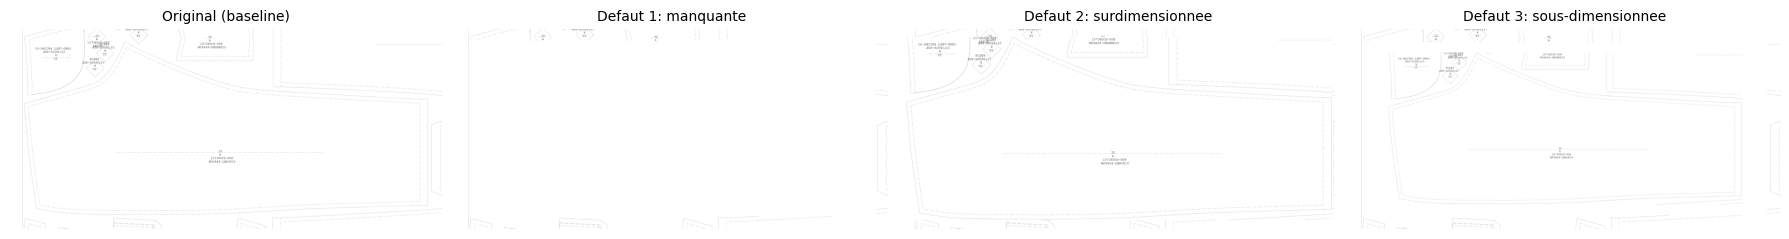

In [8]:
def crop_autour(image, bbox_px, marge=80):
    x, y, w, h = bbox_px
    x0, y0 = max(0, x - marge), max(0, y - marge)
    x1, y1 = min(image.shape[1], x + w + marge), min(image.shape[0], y + h + marge)
    return image[y0:y1, x0:x1]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img, titre in zip(
    axes,
    [image_originale, image_defaut1, image_defaut2, image_defaut3],
    ["Original (baseline)", "Defaut 1: manquante", "Defaut 2: surdimensionnee", "Defaut 3: sous-dimensionnee"],
):
    ax.imshow(crop_autour(img, piece_cible["bbox_px"]))
    ax.set_title(titre, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Resume des tests

In [9]:
print("="*70)
print("RESUME - VERIFICATION PAR INJECTION DE DEFAUTS")
print("="*70)
print(f"{'Test':30s} {'Verdict attendu':>16s} {'Verdict obtenu':>16s} {'Resultat':>10s}")
print(f"{'1. Piece manquante':30s} {'MANQUANTE':>16s} {verdict_piece_cible:>16s} {resultat_test1:>10s}")
print(f"{'2. Piece surdimensionnee':30s} {'NON CONFORME':>16s} {verdict_defaut2:>16s} {resultat_test2:>10s}")
print(f"{'3. Piece sous-dimensionnee':30s} {'NON CONFORME':>16s} {verdict_defaut3:>16s} {resultat_test3:>10s}")

tous_pass = all(r == "PASS" for r in [resultat_test1, resultat_test2, resultat_test3])
print(f"\n{'TOUS LES TESTS PASSENT' if tous_pass else 'AU MOINS UN TEST ECHOUE'} - "
      f"le pipeline {'detecte correctement' if tous_pass else 'ne detecte PAS toujours correctement'} "
      "les anomalies injectees.")

resultats_injection = {
    "tracee_test": TRACEE_TEST, "piece_cible": piece_cible["piece_reference"],
    "test_1_piece_manquante": {"attendu": "MANQUANTE", "obtenu": verdict_piece_cible, "resultat": resultat_test1},
    "test_2_surdimensionnee": {"attendu": "NON CONFORME", "obtenu": verdict_defaut2, "resultat": resultat_test2},
    "test_3_sous_dimensionnee": {"attendu": "NON CONFORME", "obtenu": verdict_defaut3, "resultat": resultat_test3},
}
with open(Path(RESULTS_DIR) / "verification_injection_defauts.json", "w") as f:
    json.dump(resultats_injection, f, indent=2)
print(f"\nSauvegarde dans {RESULTS_DIR}/verification_injection_defauts.json")

RESUME - VERIFICATION PAR INJECTION DE DEFAUTS
Test                            Verdict attendu   Verdict obtenu   Resultat
1. Piece manquante                    MANQUANTE        MANQUANTE       PASS
2. Piece surdimensionnee           NON CONFORME     NON CONFORME       PASS
3. Piece sous-dimensionnee         NON CONFORME     NON CONFORME       PASS

TOUS LES TESTS PASSENT - le pipeline detecte correctement les anomalies injectees.

Sauvegarde dans ../data/results/verification_injection_defauts.json
